# 06 - Citation Metrics & IGO Analysis


## Overview
- Load IGO (Intergovernmental Organization) detailed citation data
- Analyze relationship with HIC-Sci (Top Policy-Influential Scientists)
- Visualize inter-IGO citation networks
- Citation Gap Year analysis
- Text similarity and growth rate correlation analysis

## Outputs
- `tmp/metrics_all.pickle` - Various metrics
- `output/figures/fig_igo_network_all.eps` - IGO network figure
- `output/figures/fig_citing_igos.eps` - #Citing IGOs distribution
- `output/figures/fig_citation_gap_year.eps` - Citation Gap Year analysis
- `output/figures/fig_similarity_recent_docs.eps` - Similarity vs recent document ratio

In [1]:
# === Setup ===
import sys
sys.path.append('..')

from config.settings import (
    TmpPaths, OutputPaths, POLICY_CITE_BASE, PARTITION_NAMES
)
from src.utils import flatten
from src.data_loader import load_pickle, save_pickle

In [2]:
import glob
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as matplotlib_patches
import matplotlib.patheffects as patheffects
import seaborn as sns
import warnings
import scienceplots
from matplotlib.lines import Line2D

%matplotlib inline
%config InlineBackend.figure_format='retina'
warnings.filterwarnings('ignore')

---
## 1. Load Data

In [3]:
papers_cited_all = load_pickle(TmpPaths.POLICY_CITED_PAPER)
partition_info = load_pickle(TmpPaths.PARTITION_INFO)

partition_info['partition_name_GPT4'] = partition_info['partition_name_GPT4'].dropna().apply(
    lambda x: x.replace("&", "and")
)
partition_info.loc[10, "partition_name_GPT4"] = "Infectious Diseases"

print(f"Papers: {len(papers_cited_all)}")

Papers: 230737


In [4]:
df_all = pd.concat([
    pd.read_csv(f, on_bad_lines='skip', encoding='latin-1') 
    for f in glob.glob(str(POLICY_CITE_BASE / 'detaild_data' / 'articles-202*.csv'))
])
df_all.index = range(len(df_all))
df_all = df_all.rename(columns={'Cited by source': 'org', 'Cited by country': 'country'})
print(f"IGO citations: {len(df_all)}")

IGO citations: 1451287


In [5]:
df_all['year'] = df_all.DOI.map(papers_cited_all.set_index('doi').year)
df_all['year_cited'] = df_all['Cited by date'].apply(
    lambda x: int(x[:4]) if str(x[:4])[0] == '2' else None
)
df_all['year_diff'] = df_all['year_cited'] - df_all['year']
df_all['partition'] = df_all.DOI.map(papers_cited_all.set_index('doi').partition)

---
## 2. Add HIC-Sci Information

In [6]:
# HIC-Sci (Top Policy-Influential Scientists)
res = []
for k, v in papers_cited_all.query('partition>=0').groupby('partition'):
    hic_sci_path = TmpPaths.HIC_SCI
    if hic_sci_path.exists():
        hic_sci = set(load_pickle(hic_sci_path).loc[k])
        v['is_hic_sci'] = v.authids.apply(lambda x: 1 if len(set(x) & hic_sci) > 0 else 0)
        res.append(v['is_hic_sci'])

if res:
    papers_cited_all['is_hic_sci'] = pd.concat(res)
else:
    papers_cited_all['is_hic_sci'] = 0

papers_cited_all['is_hic_sci'] = papers_cited_all['is_hic_sci'].fillna(0)

In [7]:
# IGO citation
count_of_citing_IGOs = df_all.groupby('DOI')['org'].apply(set).apply(len)
papers_cited_all['count_of_citing_IGOs'] = papers_cited_all.doi.map(count_of_citing_IGOs)

---
## 3. IGO Dictionary & Helper Functions

In [8]:
IGO_DICT = {
    "African Development Bank": "AfDB",
    "Asian Development Bank": "ADB",
    "Food and Agriculture Organization of the United Nations": "FAO",
    "IPCC": "IPCC",
    "IPBES": "IPBES",
    "International Energy Agency": "IEA",
    "International Labour Organization": "ILO",
    "International Monetary Fund": "IMF",
    "OECD": "OECD",
    "UNESCO": "UNESCO",
    "UNHCR": "UNHCR",
    "UNICEF": "UNICEF",
    "United Nations": "UN",
    "United Nations Development Programme": "UNDP",
    "United Nations Environment Programme": "UNEP",
    "World Bank": "World Bank",
    "World Health Organization": "WHO",
    "World Trade Organization": "WTO",
    "UNAIDS": "UNAIDS",
    "Inter-American Development Bank": "IDB",
    "World Food Programme": "WFP",
    "International Renewable Energy Agency": "IRENA",
    "United Nations Framework Convention on Climate Change": "UNFCCC",
    "Africa CDC": "ACDC",
    'World Meteorological Organization':'WMO',
}

In [9]:
def get_mean(l):
    A = np.array(l)
    return A[~np.isnan(A)].mean()

---
## 4. Plot Style Settings

In [10]:
import matplotlib.pyplot as plt

plt.style.use(['science'])

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    # LaTeX 側でフォントを決めるため、ここで Arial は指定しない
    "axes.spines.right": False,
    "axes.spines.top": False,
        "xtick.top": False,
    "ytick.right": False,
})

# arial.sty を使わず、Helvetica（標準・投稿安全）
plt.rcParams["text.latex.preamble"] = r"""
\usepackage{helvet}
\usepackage{sansmath}
\sansmath
\renewcommand{\familydefault}{\sfdefault}
"""

---
## 5. Figure: #Citing IGOs Distribution (HIC-Sci vs Others)

TPIS / Others ratio: 1.698
Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../output/figures/7.pdf


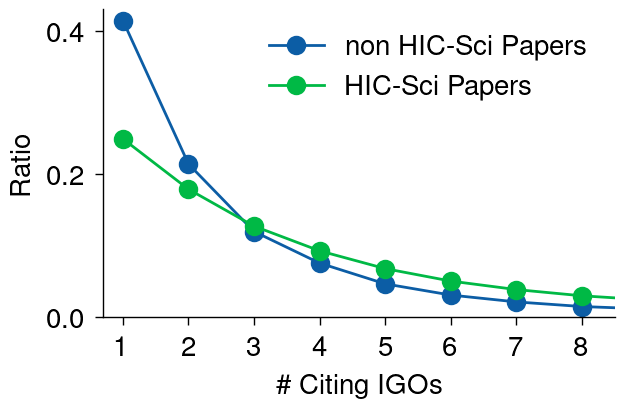

In [11]:
tmp = papers_cited_all.copy()
tmp['tmp'] = tmp.count_of_citing_IGOs

fig, ax = plt.subplots(1, 1, figsize=(3.3, 2))

(tmp.query('is_hic_sci==0').tmp.value_counts().sort_index() / len(tmp.query('is_hic_sci==0').tmp)).plot(
    ax=ax, marker='o', label='non HIC-Sci Papers'
)
(tmp.query('is_hic_sci==1').tmp.value_counts().sort_index() / len(tmp.query('is_hic_sci==1').tmp)).plot(
    ax=ax, marker='o', label='HIC-Sci Papers'
)

ax.legend()
ax.set_xlabel(r'\# Citing IGOs')
ax.set_ylabel('Ratio')
ax.set_xticks(range(1, 9))
ax.set_xticklabels(range(1, 9))
ax.set_yticks([0, 0.2, 0.4])
ax.set_xlim([0.7, 8.5])
ax.set_ylim([0.0, 0.43])
ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=False, bottom=False)

ratio = tmp.query('is_hic_sci==1').tmp.mean() / tmp.query('is_hic_sci==0').tmp.mean()
print(f"HIC-Sci / Others ratio: {ratio:.3f}")

output_path = OutputPaths.FIGURES / '7.pdf'
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path)
print(f"Saved: {output_path}")
plt.show()

---
## 6. Figure: Citation Gap Year (HIC-Sci vs Others)

In [12]:
papers_cited_all['year_diff'] = papers_cited_all.doi.map(
    df_all.groupby(['DOI'])['year_diff'].min()
)

In [13]:
plot_df = papers_cited_all.query('year <= 2023').groupby(['partition', 'is_hic_sci'])['year_diff'].agg(['mean', 'sem']).unstack()
plot_df = plot_df.iloc[1:]  # ヘッダー行除外
plot_df.index = [(partition_info.loc[i].partition_name_GPT4).replace("&", "and") 
                 for i in plot_df.index if i in partition_info.index]
plot_df = plot_df.sort_values(('mean', 0))

means = plot_df['mean']
errors = plot_df['sem']
y_positions = range(len(means))

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../output/figures/fig_citation_gap_year.pdf


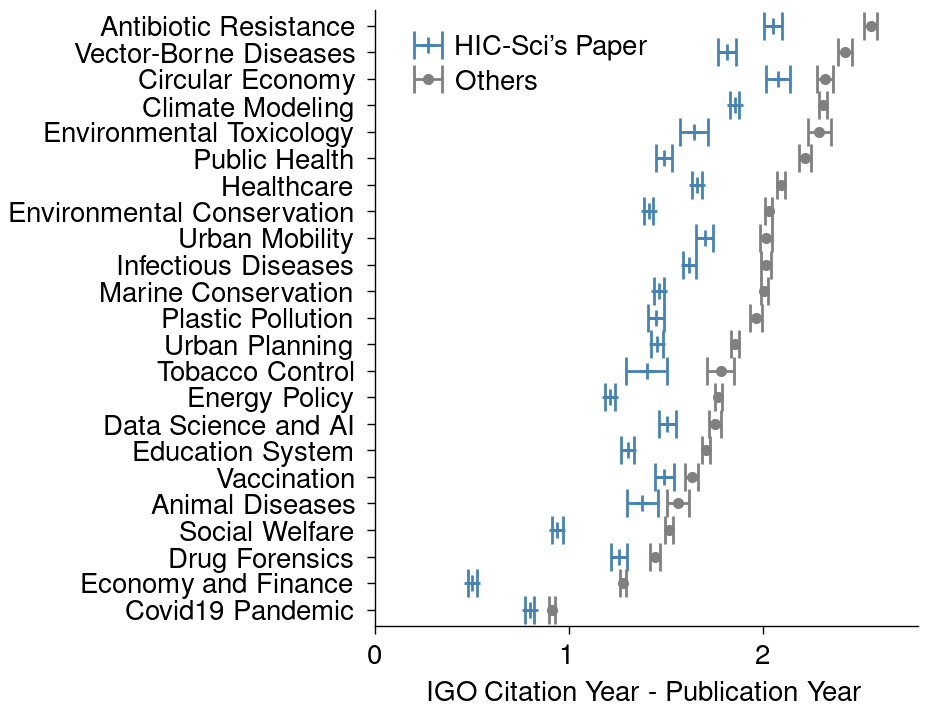

In [17]:
fig, ax = plt.subplots(figsize=(3.5, 4))

# HIC-Sci Papers (blue)
ax.errorbar(means[1], y_positions, xerr=errors[1],
            fmt="+", capsize=5, color='#4583B5', label="HIC-Sci's Paper")

# Others (gray)
ax.errorbar(means[0], y_positions, xerr=errors[0],
            fmt=".", capsize=5, color='#808080', label="Others")

ax.set_yticks(y_positions)
ax.set_yticklabels(means.index)
ax.set_xlabel('IGO Citation Year - Publication Year')
ax.set_xticks([0, 1, 2, 3])
ax.set_xlim([0, 2.8])
ax.set_ylim([-0.6, len(means) - 0.4])
ax.legend(loc="upper left", handletextpad=0, labelspacing=0.3).set_title('')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=False, bottom=False)
plt.minorticks_off()

output_path = OutputPaths.FIGURES / 'fig_citation_gap_year.eps'
fig.savefig(output_path, bbox_inches='tight')
output_path = OutputPaths.FIGURES / 'fig_citation_gap_year.pdf'
fig.savefig(output_path, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

---
## 7. Metrics Calculation

In [15]:
def get_first_mode(series):
    modes = series.mode()
    if not modes.empty:
        return modes.iloc[0]
    return np.nan

# Policy documents
policy_docs = df_all.groupby('Cited by URL').agg(
    year=('year', 'first'),
    partition=('partition', get_first_mode)
).reset_index()

In [16]:
if TmpPaths.METRICS_ALL.exists():
    res_r = load_pickle(TmpPaths.METRICS_ALL)
else:
    res_r = pd.DataFrame(index=range(23))
res_r['citation_gap_year'] = papers_cited_all.groupby('partition')['year_diff'].mean()

res_r['policy_doc_year'] = policy_docs.groupby('partition')['year'].mean()

res_r['recent_policy_doc_ratio'] = (
    policy_docs.query('year>=2019').groupby('partition')['year'].count() / 
    policy_docs.groupby('partition')['year'].count()
)

res_r

,gini,top30,hhi,nahhi,n_papers,partition_name,color,citation_gap_year,policy_doc_year,recent_policy_doc_ratio
partition,,,,,,,,,,
0.0,0.325457,0.031411,0.000060,0.000030,21208,Economy and Finance,#e6ab02,1.050433,2017.445531,0.301970
1.0,0.341006,0.011696,0.000045,0.000026,15995,Environmental Conservation,#a6761d,1.839840,2017.286097,0.264810
2.0,0.287399,0.013081,0.000039,0.000021,14412,Healthcare,#666666,1.962362,2017.113596,0.224685
3.0,0.350983,0.016471,0.000097,0.000066,13165,Energy Policy,#66c2a5,1.601405,2017.672763,0.336250
4.0,0.257532,0.029682,0.000057,0.000025,12629,Education System,#fc8d62,1.585133,2017.358753,0.293661
5.0,0.399946,0.008072,0.000071,0.000046,12372,Marine Conservation,#1b9e77,1.840545,2017.140243,0.235072
6.0,0.437961,0.008300,0.000076,0.000049,12064,Climate Modeling,#d95f02,2.168659,2017.375820,0.268041
7.0,0.325876,0.017966,0.000076,0.000045,12415,Social Welfare,#7570b3,1.341809,2017.244698,0.264162
8.0,0.176235,0.024597,0.000022,0.000007,11386,Covid19 Pandemic,#e7298a,0.876923,2019.564773,0.774306


---
## 8. Text Similarity Calculation

In [17]:
def get_sim(tmp, n_pairs=10000):
    from sklearn.metrics.pairwise import paired_cosine_distances
    
    vectors = tmp.to_numpy()
    n_rows = vectors.shape[0]
    
    idx1 = np.random.randint(0, n_rows, size=n_pairs)
    idx2 = np.random.randint(0, n_rows, size=n_pairs)
    
    vecs1 = vectors[idx1]
    vecs2 = vectors[idx2]
    
    similarities = 1 - paired_cosine_distances(vecs1, vecs2)
    return similarities.mean()

In [18]:
res = load_pickle(TmpPaths.ABSTRACT_EMBEDDING)
partiton_papers = papers_cited_all.groupby('partition').eid.apply(list)

res_r['sim'] = {
    i: get_sim(res.loc[list(set(partiton_papers[i]) & set(res.index))]) 
    for i in res_r.index if i in partiton_papers.index
}
print("Similarity calculated")

Similarity calculated


In [19]:
metrics_all = pd.read_pickle('../tmp/metrics_all.pickle')
res_r['top30'] = metrics_all['top30']

---
## 9. Figure: Similarity vs Recent Document Ratio

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../output/figures/fig_similarity_recent_docs.pdf


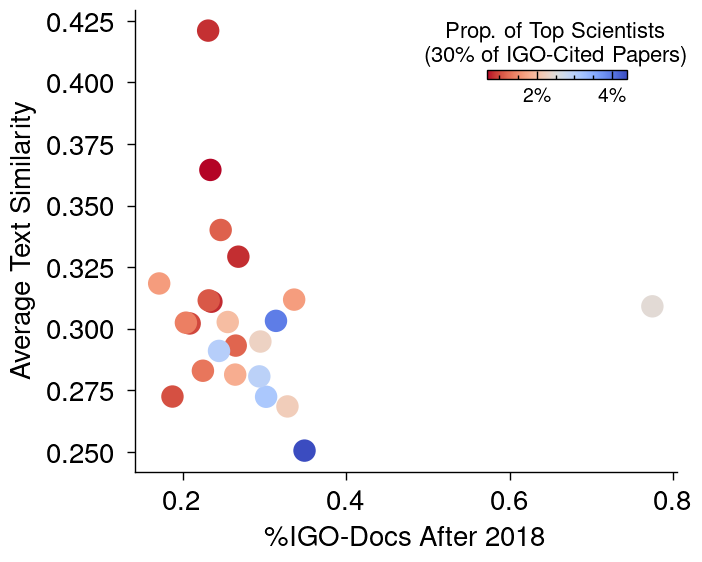

In [32]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(3.5, 3))

scatter = res_r.plot.scatter(
    x='recent_policy_doc_ratio', y='sim', c='top30', s=50,
    cmap='coolwarm_r', colorbar=False, ax=ax
)

ax.set_xlabel(r'\%IGO-Docs After 2018')
ax.set_ylabel('Average Text Similarity')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.tick_params(which='major', direction='out', left=True, bottom=True)
ax.tick_params(which='minor', direction='out', left=False, bottom=False)

list_view = [
    "Tobacco Control", "Climate Modeling", "Plastic Pollution",
    "Public Health", "Data Science and AI", "Economy and Finance",
    "Animal Diseases", "Infectious Diseases", "Covid19 Pandemic", "Vaccination"
]

if 5 in res_r.columns:  # partition nameカラムがある場合
    for idx, row in res_r.iterrows():
        if row[5] in list_view:
            ax.annotate(row[5], 
                        xy=(row['recent_policy_doc_ratio'], row['sim']),
                        xytext=(5, 0),
                        textcoords='offset points',
                        fontsize=8,
                        va='center',
                        ha='left')

pos = ax.get_position()
cbar_x = pos.x0 + pos.width * 0.65
cbar_y = pos.y0 + pos.height * 0.85
cax = fig.add_axes([cbar_x, cbar_y, 0.2, 0.015])

scatter_obj = ax.collections[0]
cbar = plt.colorbar(scatter_obj, cax=cax, orientation='horizontal')
cbar.set_label(r'Prop. of Top Scientists' '\n' r'(30\% of IGO-Cited Papers)', 
               fontsize=8, labelpad=3)
cbar.ax.xaxis.set_label_position('top')

def percent_formatter(x, pos):
    return fr'{x*100:.0f}\%'
cbar.ax.xaxis.set_major_formatter(FuncFormatter(percent_formatter))
cbar.ax.tick_params(labelsize=7)

output_path = OutputPaths.FIGURES / 'fig_similarity_recent_docs.eps'
fig.savefig(output_path, bbox_inches='tight', dpi=300)
output_path = OutputPaths.FIGURES / 'fig_similarity_recent_docs.pdf'
fig.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Saved: {output_path}")
plt.show()

---
## 10. IGO Network Construction & Visualization

In [21]:
def build_igo_network(papers_cited, df, min_count=500, weight_threshold=0.3):
    df = df[df.DOI.isin(papers_cited.doi)]
    af_country = df[['country', 'org']].groupby(['org']).agg(
        lambda x: x.value_counts().index[0]
    )['country']
    
    df = df[['DOI', 'org', 'Cited by type', 'Cited by date']].drop_duplicates().sort_values(
        ['DOI', 'Cited by date']
    ).drop_duplicates(subset=['org', 'DOI'])
    
    links = flatten([
        list(itertools.combinations(v['org'], 2)) + 
        list(itertools.combinations((v['org']).iloc[::-1], 2)) 
        for k, v in df.groupby('DOI')
    ])
    links = pd.DataFrame(links)
    links['c'] = 1
    links = links.groupby([0, 1]).count()['c'].reset_index()
    
    count_igo = df['org'].value_counts().sort_values(ascending=False)
    links['vc0'] = links[0].map(count_igo)
    links['vc1'] = links[1].map(count_igo)
    links['weight'] = links.apply(lambda x: x.c / np.min([x.vc0, x.vc1]), axis=1)
    
    view_node = pd.concat([count_igo, af_country], axis=1).dropna().query(
        f'country=="IGO" and count>={min_count}'
    ).index
    links = links[links[0].isin(view_node) & links[1].isin(view_node)]
    
    org_list = df.groupby('org').DOI.agg(set)
    df['DOI_org'] = df['DOI'] + df['org']
    DOI_org_year = df.set_index('DOI_org')['Cited by date'].apply(
        lambda x: int(x[:4]) if x[0] == '2' else None
    )
    links['DOI'] = [x & y for x, y in zip(links[0].map(org_list), links[1].map(org_list))]
    
    def compare(x, y):
        if x > y: return 1
        elif y > x: return -1
        else: return 0
    
    links['first_1'] = links.apply(
        lambda x: np.mean([compare(DOI_org_year.loc[d + x[0]], DOI_org_year.loc[d + x[1]]) 
                          for d in x['DOI']]), axis=1
    )
    links['tmp'] = links.apply(lambda x: x[0] + x[1] if x[0] < x[1] else x[1] + x[0], axis=1)
    links = pd.concat([links.query('first_1<0'), links.query('first_1==0').drop_duplicates(subset=['tmp'])])
    
    G = nx.from_pandas_edgelist(
        links.reset_index().query(f'weight>={weight_threshold}'),
        source=1, target=0, edge_attr=['weight', 'c', 'first_1'],
        create_using=nx.DiGraph()
    )
    
    return G, count_igo, df

---
## 11. Save

In [22]:
save_pickle(papers_cited_all, TmpPaths.POLICY_CITED_PAPER)
print(f"Saved: {TmpPaths.POLICY_CITED_PAPER}")

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/policy_cited_paper.pickle
Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/policy_cited_paper.pickle


In [23]:
save_pickle(res_r, TmpPaths.METRICS_ALL)
print(f"Saved: {TmpPaths.METRICS_ALL}")

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/metrics_all.pickle
Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/metrics_all.pickle


---
## 10.5. Partition-Specific IGO Networks

Generate IGO network figures for partitions [1, 6, 8, 16]

Environmental Conservation 264.58292609108986 157.8916952431814 0 United Nations CEPAL
Climate Modeling 331.0306405824151 120.6884211577308 1 Arctic Council
Climate Modeling 178.33967263385375 120.6884211577308 1 UN Office for Disaster Risk Reduction
Covid19 Pandemic 186.14233533776624 167.93688727956885 2 Pan American Health Organization (PAHO)
Covid19 Pandemic 250.253647452121 222.66911594623332 2 European Observatory on Health Systems and Policies
Data Science and AI 0.29030405502923123 -0.3547972665662424 3 United Nations Human Settlement Programme
Data Science and AI -0.7151260326497095 -0.2187723153507003 3 European Observatory on Health Systems and Policies
Data Science and AI -0.12980943814398446 -0.2187723153507003 3 UNCTAD
Data Science and AI -0.022336524534200985 -0.2187723153507003 3 Pan American Health Organization (PAHO)
Data Science and AI -0.2304723494582598 -0.2187723153507003 3 United Nations ECE
Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../output/figur

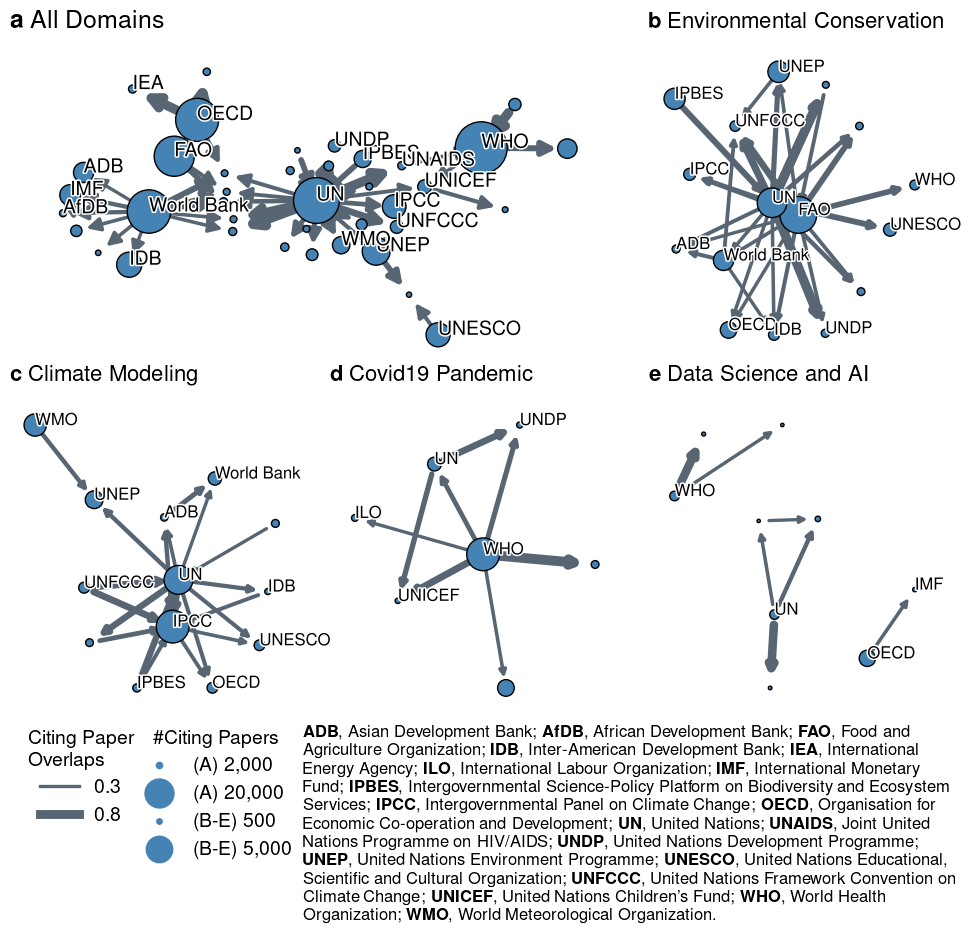

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as matplotlib_patches
from matplotlib.lines import Line2D
import matplotlib.patheffects as patheffects
import networkx as nx
import numpy as np
import pandas as pd
import itertools

fig = plt.figure(figsize=(6, 5))
gs = gridspec.GridSpec(3, 3, height_ratios=[2, 2, 0.4], hspace=0.15, wspace=0.1)

ax_all = fig.add_subplot(gs[0, 0:2])      # 全体（幅2）
ax_p1 = fig.add_subplot(gs[0, 2])          # 分野1（幅1）
ax_p2 = fig.add_subplot(gs[1, 0])          # 分野2
ax_p3 = fig.add_subplot(gs[1, 1])          # 分野3
ax_p4 = fig.add_subplot(gs[1, 2])          # 分野4
ax_legend = fig.add_subplot(gs[2, :])      # 凡例（全幅）

TARGET_PARTITIONS = [1, 6, 8, 16]
partition_axes = [ax_p1, ax_p2, ax_p3, ax_p4]

IGOs_plotted = []

# ========== 全体のIGOネットワーク ==========
G, count_igo, df_filtered = build_igo_network(papers_cited_all, df_all)

node_size_all = None
scale_all = None

if len(G.nodes()) > 0:
    pos_p = nx.nx_agraph.graphviz_layout(G, prog="neato")
    
    theta = np.radians(150)
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    pos_p = {node: np.dot(rotation_matrix, coord) for node, coord in pos_p.items()}
    
    node_size_all = df_filtered['org'].value_counts()
    scale_all = 350 / node_size_all.max()  # 1000 -> 700 に縮小
    
    nx.draw_networkx_nodes(
        G, node_size=[node_size_all[n] * scale_all for n in G.nodes()],
        node_color="#4583B5", linewidths=0.5, edgecolors="black", pos=pos_p, ax=ax_all
    )
    
    edge_widths = [G[u][v]['weight'] * 4 for u, v in G.edges()]
    testArrow = matplotlib_patches.ArrowStyle.CurveFilledA()
    nx.draw_networkx_edges(
        G, edge_color="#586673", arrowstyle=testArrow, arrowsize=10,
        width=edge_widths, pos=pos_p, ax=ax_all,min_source_margin=0, min_target_margin=0 , node_size=55
    )
    
    for n in [n for n in count_igo.index if n in G.nodes()][:30]:
        if n in IGO_DICT:
            IGOs_plotted.append(n)
            ax_all.text(
                pos_p[n][0], pos_p[n][1], IGO_DICT[n], size=7,
                path_effects=[patheffects.withStroke(linewidth=1.1, foreground='white', capstyle="round")]
            )

ax_all.set_title(r"\textbf{a} All Domains", loc='left', fontsize=9)
ax_all.axis('off')

all_partition_max = 0
for partition in TARGET_PARTITIONS:
    papers_cited = papers_cited_all.query('partition == @partition')
    df_tmp = df_all[df_all.DOI.isin(papers_cited.doi)]
    df_tmp = df_tmp[['DOI', 'org', 'Cited by type', 'Cited by date']].drop_duplicates().sort_values(
        ['DOI', 'Cited by date']
    ).drop_duplicates(subset=['org', 'DOI'])
    if len(df_tmp) > 0:
        current_max = df_tmp['org'].value_counts().max()
        if current_max > all_partition_max:
            all_partition_max = current_max
scale_cluster = 175 / all_partition_max if all_partition_max > 0 else 1

subplot_labels = ['b', 'c', 'd', 'e']
partition_scales = {}

for idx, (partition, ax) in enumerate(zip(TARGET_PARTITIONS, partition_axes)):
    papers_cited = papers_cited_all.query('partition == @partition')
    
    df = df_all[df_all.DOI.isin(papers_cited.doi)]
    af_country = df[['country', 'org']].groupby(['org']).agg(
        lambda x: x.value_counts().index[0]
    )['country']
    
    df = df[['DOI', 'org', 'Cited by type', 'Cited by date']].drop_duplicates().sort_values(
        ['DOI', 'Cited by date']
    ).drop_duplicates(subset=['org', 'DOI'])
    
    links = flatten([
        list(itertools.combinations(v['org'], 2)) + 
        list(itertools.combinations((v['org']).iloc[::-1], 2)) 
        for k, v in df.groupby('DOI')
    ])
    links = pd.DataFrame(links)
    links['c'] = 1
    links = links.groupby([0, 1]).count()['c'].reset_index()
    
    count_igo = df['org'].value_counts().sort_values(ascending=False)
    links['vc0'] = links[0].map(count_igo)
    links['vc1'] = links[1].map(count_igo)
    links['weight'] = links.apply(lambda x: x.c / np.min([x.vc0, x.vc1]), axis=1)
    
    limit = partition_info.num_paper.dropna().loc[partition] / 80
    view_node = pd.concat([count_igo, af_country], axis=1).dropna().query(
        f'country=="IGO" and count>={limit}'
    ).index
    
    links = links[links[0].isin(view_node) & links[1].isin(view_node)]
    
    if len(links) == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue
    
    node_size = df['org'].value_counts()
    org_list = df.groupby('org').DOI.agg(set)
    df['DOI_org'] = df['DOI'] + df['org']
    DOI_org_year = df.set_index('DOI_org')['Cited by date'].apply(
        lambda x: int(x[:4]) if str(x)[0] == '2' else None
    )
    links['DOI'] = [x & y for x, y in zip(links[0].map(org_list), links[1].map(org_list))]
    
    def compare(x, y):
        if pd.isna(x) or pd.isna(y): return 0
        if x > y: return 1
        elif y > x: return -1
        else: return 0
    
    links['first_1'] = links.apply(
        lambda x: np.mean([compare(
            DOI_org_year.get(d + x[0], np.nan), 
            DOI_org_year.get(d + x[1], np.nan)
        ) for d in x['DOI']]), axis=1
    )
    links['tmp'] = links.apply(lambda x: x[0] + x[1] if x[0] < x[1] else x[1] + x[0], axis=1)
    links = pd.concat([links.query('first_1<0'), links.query('first_1==0').drop_duplicates(subset=['tmp'])])
    
    G = nx.from_pandas_edgelist(
        links.reset_index().query('weight>=0.3'),
        source=1, target=0, edge_attr=['weight', 'c', 'first_1'],
        create_using=nx.DiGraph()
    )
    
    if len(G.nodes()) == 0:
        ax.text(0.5, 0.5, "No nodes", ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        continue
    
    if partition == 16:
        pos_p = nx.spring_layout(G, seed=701, scale=1, iterations=15)
    else:
        pos_p = nx.nx_agraph.graphviz_layout(G, prog="neato")
    
    theta = np.radians(200 if partition == 16 else 20)
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    pos_p = {node: np.dot(rotation_matrix, coord) for node, coord in pos_p.items()}
    
    scale = scale_cluster
    partition_scales[partition] = {'scale': scale, 'max': node_size.max()}
    
    nx.draw_networkx_nodes(
        G, node_size=[node_size[n] * scale for n in G.nodes()],
        node_color="#4583B5", linewidths=0.5, edgecolors="black", pos=pos_p, ax=ax
    )
    
    edge_widths = [G[u][v]['weight'] * 4 for u, v in G.edges()]
    testArrow = matplotlib_patches.ArrowStyle.CurveFilledA()
    nx.draw_networkx_edges(
        G, edge_color="#586673", arrowstyle=testArrow, arrowsize=5,
        width=edge_widths, pos=pos_p, ax=ax,min_source_margin=0, min_target_margin=0, node_size=55
    )
    partition_name = partition_info.partition_name_GPT4.loc[partition]
    # ラベル
    for n in [n for n in count_igo.index if n in G.nodes()][:14]:
        if n in IGO_DICT:
            IGOs_plotted.append(n)
            pos_y = pos_p[n][1]
            if IGO_DICT[n] == "UN ECE":
                pos_y = 0.22
            elif IGO_DICT[n] == "UN-Habitat":
                pos_y = 0.05
            
            ax.text(
                pos_p[n][0], pos_y, IGO_DICT[n], size=6,
                path_effects=[patheffects.withStroke(linewidth=1.1, foreground='white', capstyle="round")]
            )
        else:

            print(partition_name,pos_p[n][0], pos_y, idx,n)
    
    
    ax.set_title(rf"\textbf{{{subplot_labels[idx]}}} {partition_name}", loc='left', fontsize=8)
    ax.axis('off')

ax_legend.axis('off')

edge_legends = [Line2D([0], [0], color="#586673", lw=e * 4, label=f"Overlap = {e}") for e in [0.3, 0.8]]

node_legend_all = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4583B5",
           markersize=np.sqrt(size * scale_all), label=f"(A) {size:,}")
    for size in [2000, 20000]
]

if partition_scales:
    node_legend_cluster = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#4583B5",
               markersize=np.sqrt(size * scale_cluster), label=f"(B-E) {size:,}")
        for size in [500, 5000]
    ]
else:
    node_legend_cluster = []


ax_legend.axis('off')

# ---  Citing Paper Overlaps (OC) ---
edge_legends = [
    Line2D([0], [0], color="#586673", lw=0.3 * 4, label="0.3"),
    Line2D([0], [0], color="#586673", lw=0.8 * 4, label="0.8")
]

legend1 = ax_legend.legend(
    handles=edge_legends,
    ncol=1,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.6),
    frameon=False,
    fontsize=7,
    title="Citing Paper \n Overlaps",
    title_fontsize=7
)
ax_legend.add_artist(legend1)

# ---  #Citing Papers ---
node_legend_all = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#4583B5",
           markersize=np.sqrt(size * scale_all), label=f"(A) {size:,}")
    for size in [2000, 20000]
]

if partition_scales:
    node_legend_cluster = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor="#4583B5",
               markersize=np.sqrt(size * scale_cluster), label=f"(B-E) {size:,}")
        for size in [500, 5000]
    ]
else:
    node_legend_cluster = []

legend2 = ax_legend.legend(
    handles=node_legend_all + node_legend_cluster,
    ncol=1,
    loc="upper left",
    bbox_to_anchor=(0.12, 1.6), 
    frameon=False,
    fontsize=7,
    title=r"\#Citing Papers",
    title_fontsize=7
)


igo_names = [
    ['ADB', 'Asian Development Bank'],
    ['AfDB', 'African Development Bank'],
    ['FAO', 'Food and Agriculture Organization'],
    ['IDB', 'Inter-American Development Bank'],
    ['IEA', 'International Energy Agency'],
    ['ILO', 'International Labour Organization'],
    ['IMF', 'International Monetary Fund'],
    ['IPBES', 'Intergovernmental Science-Policy Platform on Biodiversity and Ecosystem Services'],
    ['IPCC', 'Intergovernmental Panel on Climate Change'],
    ['OECD', 'Organisation for Economic Co-operation and Development'],
    ['UN', 'United Nations'],
    ['UNAIDS', 'Joint United Nations Programme on HIV/AIDS'],
    ['UNDP', 'United Nations Development Programme'],
    ['UNEP', 'United Nations Environment Programme'],
    ['UNESCO', 'United Nations Educational, Scientific and Cultural Organization'],
    ['UNFCCC', 'United Nations Framework Convention on Climate Change'],
    ['UNICEF', "United Nations Children's Fund"],
    ['WHO', 'World Health Organization'],
    ['WMO','World Meteorological Organization'],

]

import textwrap


legend_parts = [rf"$\bf{{{abbr}}}$, {full}" for abbr, full in sorted(igo_names)]
full_text = "; ".join(legend_parts) + "."

wrapped_text = textwrap.fill(full_text, width=100, break_long_words=True)

wrapped_text = """$\\bf{ADB}$, Asian Development Bank; $\\bf{AfDB}$, African Development Bank; $\\bf{FAO}$, Food and
Agriculture Organization; $\\bf{IDB}$, Inter-American Development Bank; $\\bf{IEA}$, International
Energy Agency; $\\bf{ILO}$, International Labour Organization; $\\bf{IMF}$, International Monetary
Fund; $\\bf{IPBES}$, Intergovernmental Science-Policy Platform on Biodiversity and Ecosystem
Services; $\\bf{IPCC}$, Intergovernmental Panel on Climate Change; $\\bf{OECD}$, Organisation for
Economic Co-operation and Development; $\\bf{UN}$, United Nations; $\\bf{UNAIDS}$, Joint United
Nations Programme on HIV/AIDS; $\\bf{UNDP}$, United Nations Development Programme; 
$\\bf{UNEP}$, United Nations Environment Programme; $\\bf{UNESCO}$, United Nations Educational, 
Scientific and Cultural Organization; $\\bf{UNFCCC}$, United Nations Framework Convention on
Climate Change; $\\bf{UNICEF}$, United Nations Children's Fund; $\\bf{WHO}$, World Health 
Organization; $\\bf{WMO}$, World Meteorological Organization."""

# Abbreviations
ax_legend.text(0.315, 1.4, wrapped_text, ha='left', va='top', fontsize=6,
               transform=ax_legend.transAxes, linespacing=1.2)

output_path = OutputPaths.FIGURES / 'fig_igo_network_combined.eps'
fig.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
output_path = OutputPaths.FIGURES / 'fig_igo_network_combined.pdf'
fig.savefig(output_path, bbox_inches='tight', pad_inches=0.05)
print(f"Saved: {output_path}")
plt.show()

---
## Output Summary

| File | Description |
|------|-------------|
| `tmp/policy_cited_paper.pickle` | Updated (is_hic_sci, count_of_citing_IGOs added) |
| `tmp/metrics_all.pickle` | Partition-level metrics |
| `output/figures/fig_citing_igos.eps` | #Citing IGOs distribution |
| `output/figures/fig_citation_gap_year.eps` | Citation Gap Year analysis |
| `output/figures/fig_similarity_recent_docs.eps` | Similarity vs recent document ratio |
| `output/figures/fig_igo_network_all.eps` | IGO network figure (all) |
| `output/figures/7_igo_connection/{partition}.eps` | Partition-specific IGO network figures |